# 01 - Esplorazione del dataset WESAD

Obiettivo del notebook:

- caricare un soggetto del dataset WESAD;
- capire la struttura del file `.pkl`;
- controllare i segnali disponibili;
- osservare la distribuzione delle label;
- visualizzare alcuni segnali fisiologici di base.

In questa prima fase non addestriamo modelli e non estraiamo ancora feature.

## 1. Import delle librerie

In [1]:
import os
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import kagglehub
except ImportError:
    kagglehub = None

## 2. Controllo dei file disponibili su Kaggle

Su Kaggle i dataset collegati al notebook sono disponibili nella cartella `/kaggle/input`.

In [2]:
KAGGLE_INPUT_PATH = Path("/kaggle/input")

if KAGGLE_INPUT_PATH.exists():
    printed = 0
    for dirname, _, filenames in os.walk(KAGGLE_INPUT_PATH):
        for filename in filenames:
            print(os.path.join(dirname, filename))
            printed += 1
            if printed >= 30:
                print("...")
                break
        if printed >= 30:
            break
else:
    print("Cartella /kaggle/input non trovata. Se lavori in locale, imposta manualmente DATASET_PATH nella prossima cella.")

/kaggle/input/datasets/mohamedasem318/wesad-full-dataset/README.txt
/kaggle/input/datasets/mohamedasem318/wesad-full-dataset/LICENSE.txt
/kaggle/input/datasets/mohamedasem318/wesad-full-dataset/WESAD/wesad_readme.pdf
/kaggle/input/datasets/mohamedasem318/wesad-full-dataset/WESAD/S14/S14.pkl
/kaggle/input/datasets/mohamedasem318/wesad-full-dataset/WESAD/S14/S14_quest.csv
/kaggle/input/datasets/mohamedasem318/wesad-full-dataset/WESAD/S14/S14_respiban.txt
/kaggle/input/datasets/mohamedasem318/wesad-full-dataset/WESAD/S14/S14_readme.txt
/kaggle/input/datasets/mohamedasem318/wesad-full-dataset/WESAD/S14/S14_E4_Data/HR.csv
/kaggle/input/datasets/mohamedasem318/wesad-full-dataset/WESAD/S14/S14_E4_Data/IBI.csv
/kaggle/input/datasets/mohamedasem318/wesad-full-dataset/WESAD/S14/S14_E4_Data/BVP.csv
/kaggle/input/datasets/mohamedasem318/wesad-full-dataset/WESAD/S14/S14_E4_Data/EDA.csv
/kaggle/input/datasets/mohamedasem318/wesad-full-dataset/WESAD/S14/S14_E4_Data/info.txt
/kaggle/input/datasets/moh

## 3. Path del dataset

Se il dataset e' gia' collegato al notebook Kaggle, il path viene trovato automaticamente.

Se si lavora in locale, modificare `LOCAL_DATASET_PATH` con il percorso della cartella `WESAD`.

In [3]:
LOCAL_DATASET_PATH = Path("data/raw/WESAD")
KAGGLE_DATASET_SLUG = "mohamedasem318/wesad-full-dataset"

def find_wesad_path():
    expected_kaggle_path = Path("/kaggle/input/datasets/mohamedasem318/wesad-full-dataset/WESAD")
    if expected_kaggle_path.exists():
        return expected_kaggle_path

    if KAGGLE_INPUT_PATH.exists():
        matches = list(KAGGLE_INPUT_PATH.rglob("WESAD"))
        if matches:
            return matches[0]

    if LOCAL_DATASET_PATH.exists():
        return LOCAL_DATASET_PATH

    if kagglehub is not None:
        downloaded_path = Path(kagglehub.dataset_download(KAGGLE_DATASET_SLUG))
        wesad_path = downloaded_path / "WESAD"
        if wesad_path.exists():
            return wesad_path

    raise FileNotFoundError("Dataset WESAD non trovato. Collegalo su Kaggle oppure imposta LOCAL_DATASET_PATH.")

DATASET_PATH = find_wesad_path()
print("DATASET_PATH:", DATASET_PATH)

SUBJECT_ID = "S15"
subject_path = DATASET_PATH / SUBJECT_ID / f"{SUBJECT_ID}.pkl"

print(subject_path)
print("File trovato:", subject_path.exists())

DATASET_PATH: /kaggle/input/datasets/mohamedasem318/wesad-full-dataset/WESAD
/kaggle/input/datasets/mohamedasem318/wesad-full-dataset/WESAD/S15/S15.pkl
File trovato: True


## 4. Caricamento di un soggetto

In [4]:
with open(subject_path, "rb") as f:
    data = pickle.load(f, encoding="latin1")

print(type(data))
print(data.keys())

<class 'dict'>
dict_keys(['signal', 'label', 'subject'])


## 5. Struttura dei segnali

In [5]:
print("Chiavi dentro data['signal']:")
print(data["signal"].keys())

print("\nSegnali chest:")
print(data["signal"]["chest"].keys())

print("\nSegnali wrist:")
print(data["signal"]["wrist"].keys())

Chiavi dentro data['signal']:
dict_keys(['chest', 'wrist'])

Segnali chest:
dict_keys(['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp'])

Segnali wrist:
dict_keys(['ACC', 'BVP', 'EDA', 'TEMP'])


## 6. Dimensione dei segnali chest

In [6]:
chest = data["signal"]["chest"]
labels = data["label"]

for signal_name, values in chest.items():
    print(signal_name, values.shape)

print("Label:", labels.shape)

ACC (3676400, 3)
ECG (3676400, 1)
EMG (3676400, 1)
EDA (3676400, 1)
Temp (3676400, 1)
Resp (3676400, 1)
Label: (3676400,)


## 7. Distribuzione delle label

Nel progetto useremo inizialmente queste label:

- `1 = baseline`
- `2 = stress`
- `3 = amusement`

Le altre label verranno ignorate nella prima versione.

In [7]:
label_counts = pd.Series(labels).value_counts().sort_index()
label_counts

0    1457401
1     822500
2     480200
3     260400
4     555799
5      35000
6      32900
7      32200
Name: count, dtype: int64

In [8]:
label_names = {
    0: "transient/undefined",
    1: "baseline",
    2: "stress",
    3: "amusement",
    4: "meditation"
}

label_summary = pd.DataFrame({
    "label": label_counts.index,
    "name": [label_names.get(label, "unknown") for label in label_counts.index],
    "count": label_counts.values
})

label_summary

,label,name,count
0,0,transient/undefined,1457401
1,1,baseline,822500
2,2,stress,480200
3,3,amusement,260400
4,4,meditation,555799
5,5,unknown,35000
6,6,unknown,32900
7,7,unknown,32200


## 8. Creazione di un DataFrame semplice

Per visualizzare i segnali principali creiamo un DataFrame con alcune colonne chest e la label.

In [9]:
df = pd.DataFrame({
    "ECG": chest["ECG"].flatten(),
    "EDA": chest["EDA"].flatten(),
    "EMG": chest["EMG"].flatten(),
    "Resp": chest["Resp"].flatten(),
    "Temp": chest["Temp"].flatten(),
    "Label": labels
})

df.head()

,ECG,EDA,EMG,Resp,Temp,Label
0,-0.025543,1.362228,-0.016159,0.691223,33.493042,0
1,-0.012955,1.357651,-0.014145,0.694275,33.447693,0
2,0.002518,1.345444,-0.013000,0.695801,33.480957,0
3,0.008011,1.353073,-0.003204,0.689697,33.499084,0
4,0.007141,1.344299,-0.000687,0.682068,33.493042,0


## 9. Filtraggio delle label utili

In [10]:
useful_labels = [1, 2, 3]
df_useful = df[df["Label"].isin(useful_labels)].copy()

df_useful["BinaryLabel"] = np.where(df_useful["Label"] == 2, "stress", "non-stress")

print(df_useful.shape)
df_useful[["Label", "BinaryLabel"]].value_counts().sort_index()

(1563100, 7)


Label  BinaryLabel
1      non-stress     822500
2      stress         480200
3      non-stress     260400
Name: count, dtype: int64

## 10. Visualizzazione dei segnali

Per non rendere i grafici troppo pesanti visualizziamo solo un piccolo intervallo di campioni.

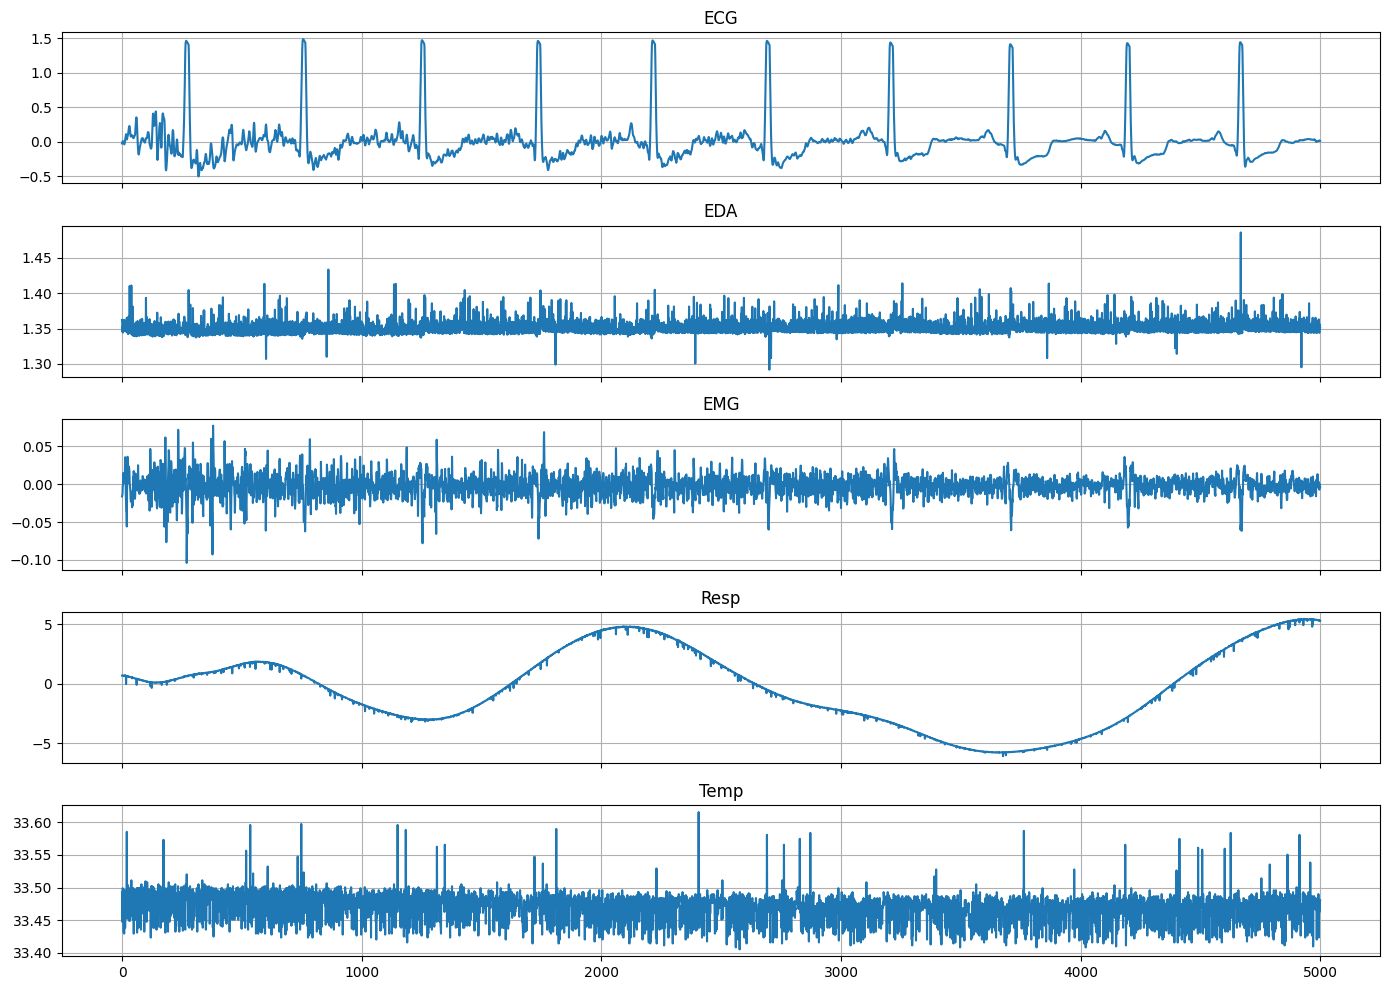

In [11]:
start = 0
end = 5000

signals_to_plot = ["ECG", "EDA", "EMG", "Resp", "Temp"]

fig, axes = plt.subplots(len(signals_to_plot), 1, figsize=(14, 10), sharex=True)

for ax, signal_name in zip(axes, signals_to_plot):
    ax.plot(df[signal_name].iloc[start:end])
    ax.set_title(signal_name)
    ax.grid(True)

plt.tight_layout()
plt.show()